# Posterior-Only Visualization

This notebook uses only the files present in the posterior directory: posterior samples, posterior mean/std if available, and metadata. It does not require truth or data maps.

In [12]:
from pathlib import Path
import json

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## Load Posterior Files

In [13]:
fname = Path("/Users/tsouros/Desktop/misc/posterior/")

metadata_path = fname / "metadata.json"
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}

samples_path = fname / "posterior_samples_I.npy"
mean_path = fname / "posterior_mean_I.fits"
std_path = fname / "posterior_std_I.fits"

samples = np.load(samples_path)
if samples.ndim == 1:
    samples = samples[None, :]

posterior_mean = np.asarray(hp.read_map(mean_path, field=0, dtype=np.float64)) if mean_path.exists() else None
posterior_std = np.asarray(hp.read_map(std_path, field=0, dtype=np.float64)) if std_path.exists() else None

n_samples, npix = samples.shape
nside = hp.npix2nside(npix)
print(f"nside={nside}, npix={npix}, n_samples={n_samples}")
metadata

nside=128, npix=196608, n_samples=10


{'data_fits': '/lustre/fswork/projects/rech/pmr/uee28se/nifty8_healpix_denoising/synthetic_q_nside128_10samples/synthetic_data_Q.fits',
 'component': 'I',
 'input_nside': 128,
 'analysis_nside': 128,
 'nest': False,
 'noise_model': 'd = s + n, n_p ~ Normal(0, sigma_n^2) iid',
 'noise_sigma': 0.3915566821767549,
 'noise_sigma_source': 'cli',
 'posterior_samples': 10,
 'vi_iterations': 3,
 'geovi': False,
 'prior': {'type': 'NIFTy8 CorrelatedFieldMaker on HPSpace',
  'loglog_slope_mean': -2.4,
  'loglog_slope_std': 0.5,
  'fluctuations': [1.0, 0.5],
  'flexibility': [0.5, 0.5],
  'asperity': [0.0, 0.5]},
 'latent_keys': ['dust_qflexibility',
  'dust_qfluctuations',
  'dust_qloglogavgslope',
  'dust_qspectrum',
  'dust_qxi',
  'dust_qzeromode']}

## Choose One Posterior Sample

/Users/tsouros/anaconda3/envs/stl/lib/python3.11/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


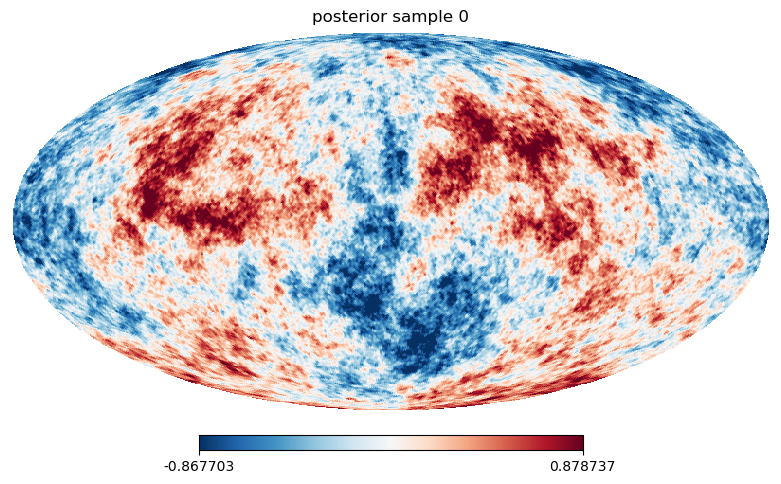

In [14]:
SAMPLE_INDEX = 0
sample = samples[SAMPLE_INDEX]

vals = sample[np.isfinite(sample)]
vmin, vmax = np.percentile(vals, [1, 99])

fig = plt.figure(figsize=(8, 5))
hp.mollview(sample, fig=fig.number, title=f"posterior sample {SAMPLE_INDEX}", cmap="RdBu_r", min=vmin, max=vmax)
plt.show()

## Draw All Posterior Samples

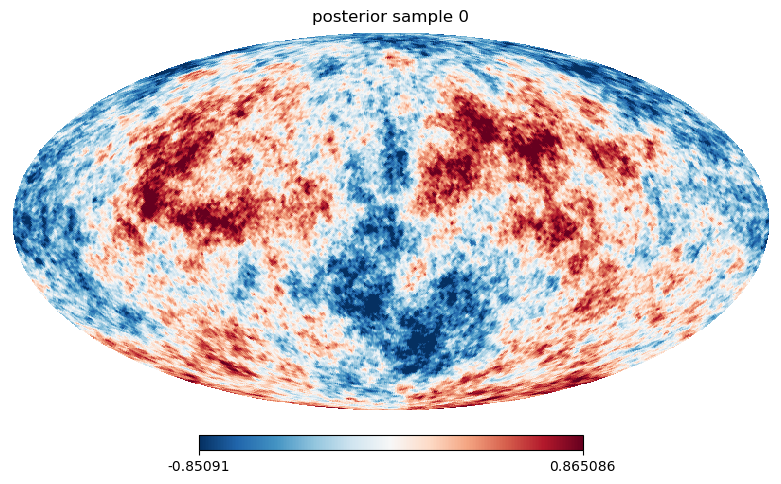

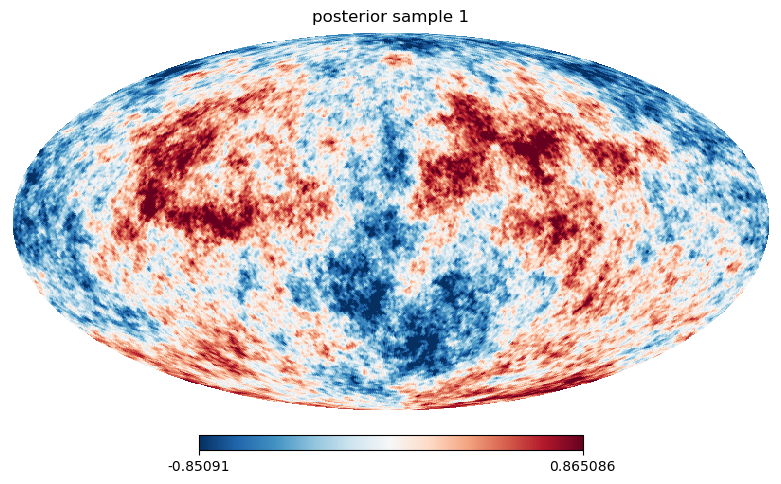

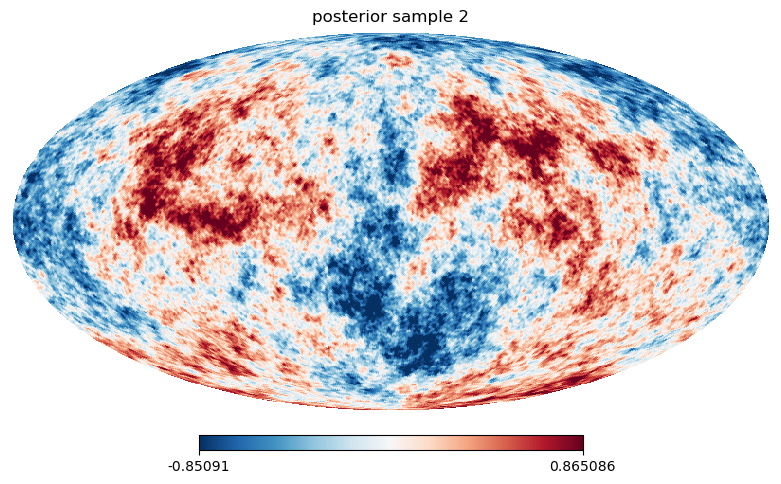

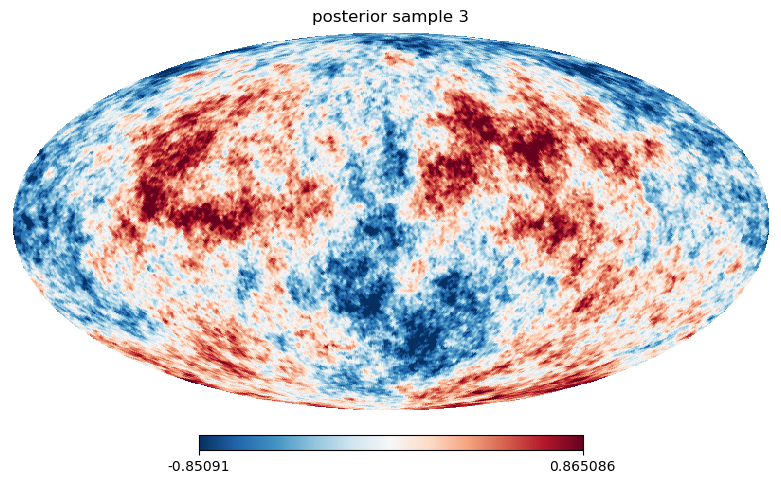

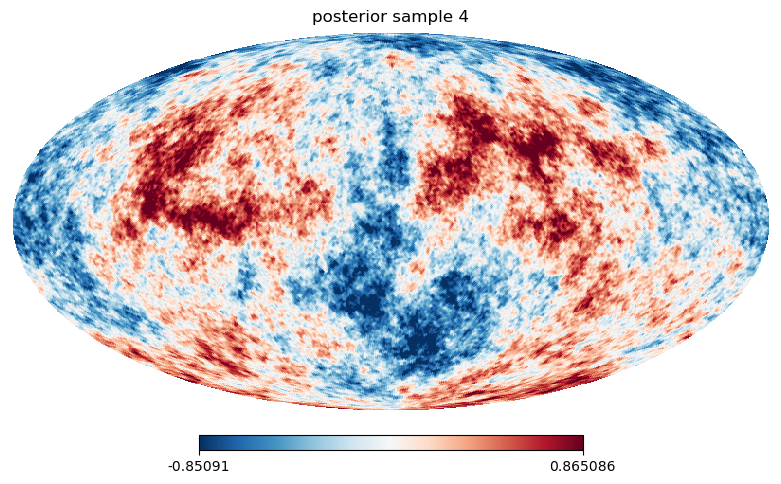

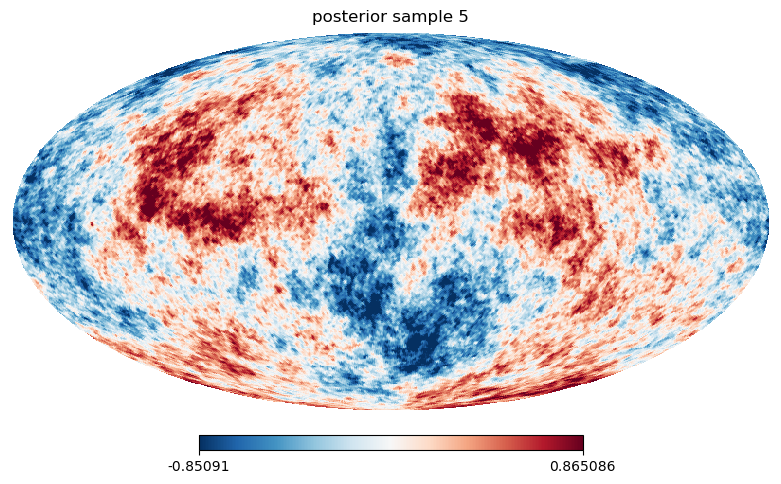

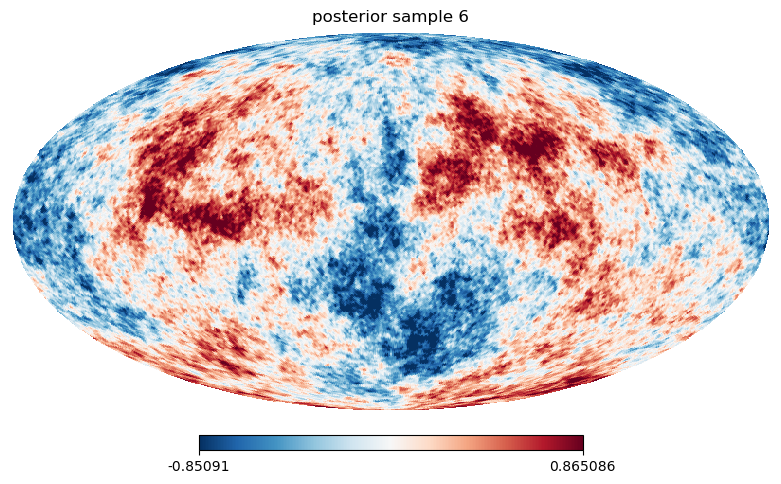

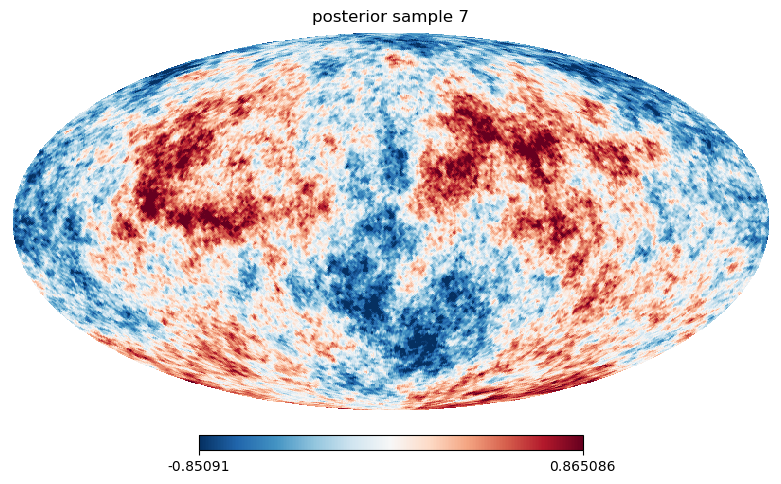

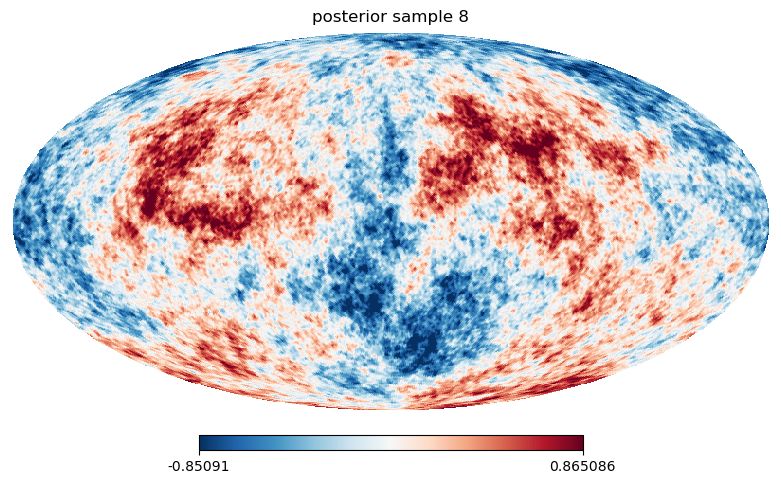

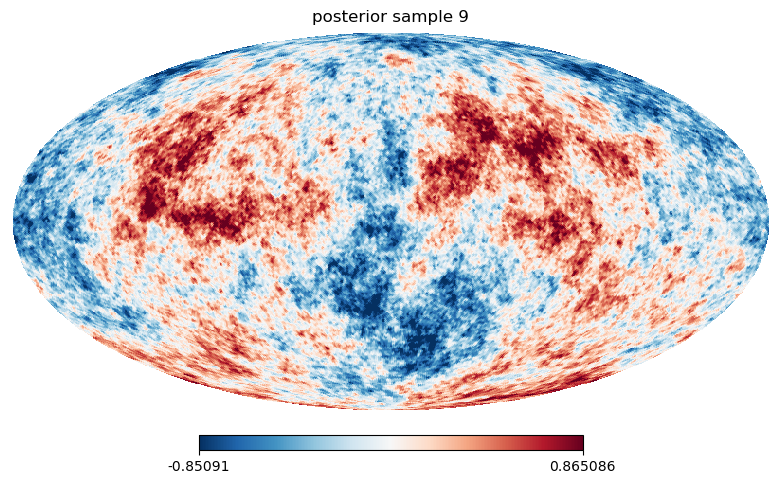

In [15]:
all_vals = samples[np.isfinite(samples)]
vmin, vmax = np.percentile(all_vals, [1, 99])

for i, sample in enumerate(samples):
    fig = plt.figure(figsize=(8, 5))
    hp.mollview(sample, fig=fig.number, title=f"posterior sample {i}", cmap="RdBu_r", min=vmin, max=vmax)
    plt.show()

## Posterior Mean and Std

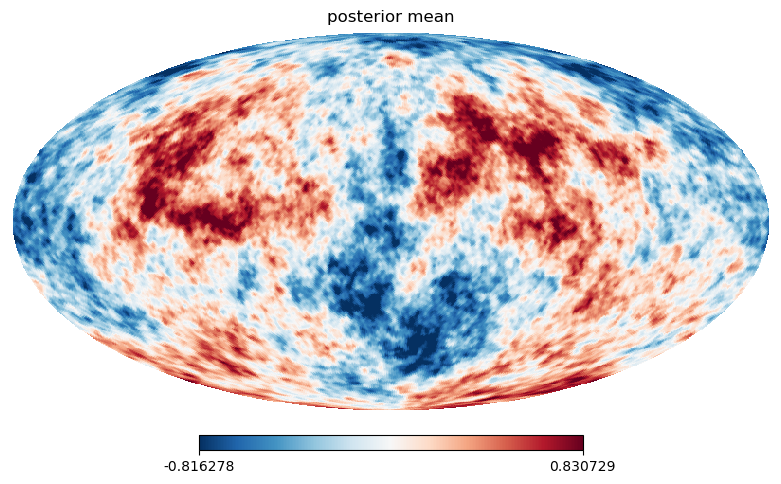

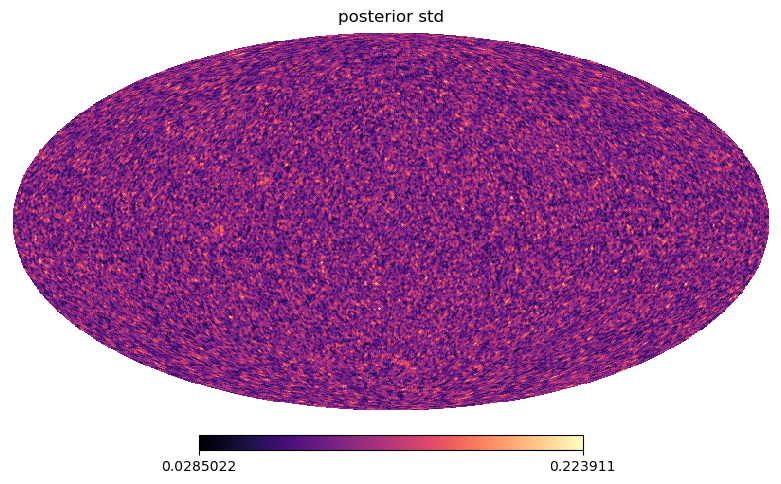

In [16]:
if posterior_mean is not None:
    vals = posterior_mean[np.isfinite(posterior_mean)]
    vmin, vmax = np.percentile(vals, [1, 99])
    fig = plt.figure(figsize=(8, 5))
    hp.mollview(posterior_mean, fig=fig.number, title="posterior mean", cmap="RdBu_r", min=vmin, max=vmax)
    plt.show()

if posterior_std is not None:
    fig = plt.figure(figsize=(8, 5))
    hp.mollview(posterior_std, fig=fig.number, title="posterior std", cmap="magma")
    plt.show()

## Posterior Sample Power Spectra

Samples are plotted with `alpha = 0.4`. The posterior mean spectrum is shown if available.

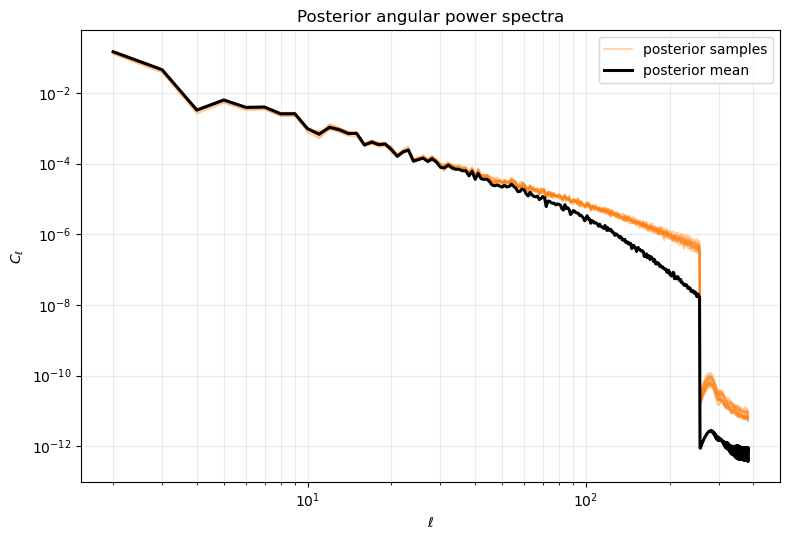

In [17]:
def cl(map_, lmax=None):
    map_ = np.asarray(map_, dtype=np.float64)
    map_ = map_ - np.mean(map_[np.isfinite(map_)])
    return hp.anafast(map_, lmax=lmax)

lmax = min(3 * nside - 1, 512)
ell = np.arange(lmax + 1)
cl_samples = np.stack([cl(sample, lmax=lmax) for sample in samples], axis=0)
cl_mean = cl(posterior_mean, lmax=lmax) if posterior_mean is not None else None

plt.figure(figsize=(8, 5.5))
for i, cls in enumerate(cl_samples):
    plt.loglog(ell[2:], cls[2:], color="tab:orange", alpha=0.4, lw=1.2, label="posterior samples" if i == 0 else None)
if cl_mean is not None:
    plt.loglog(ell[2:], cl_mean[2:], color="black", lw=2.2, label="posterior mean")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.title("Posterior angular power spectra")
plt.grid(alpha=0.25, which="both")
plt.legend()
plt.tight_layout()
plt.show()

## Optional: $D_\ell$ Plot

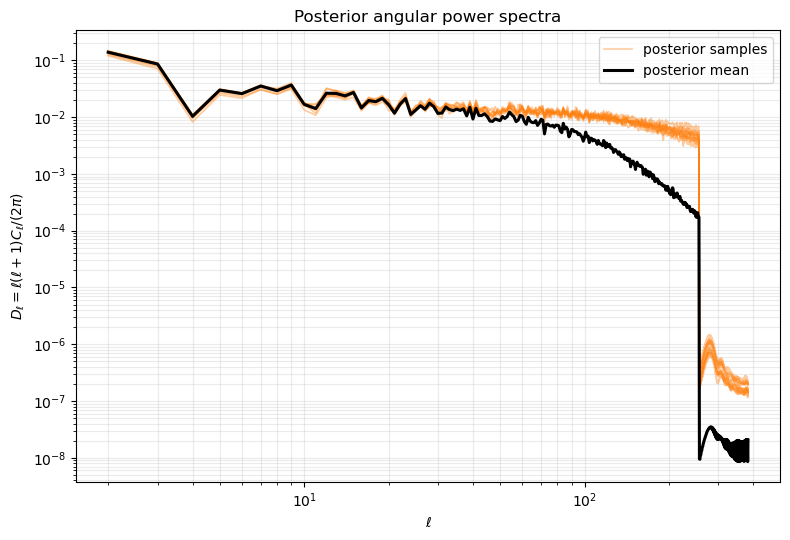

In [18]:
dl_samples = cl_samples * ell[None, :] * (ell[None, :] + 1) / (2 * np.pi)
dl_mean = cl_mean * ell * (ell + 1) / (2 * np.pi) if cl_mean is not None else None

plt.figure(figsize=(8, 5.5))
for i, dls in enumerate(dl_samples):
    plt.loglog(ell[2:], dls[2:], color="tab:orange", alpha=0.4, lw=1.2, label=r"posterior samples" if i == 0 else None)
if dl_mean is not None:
    plt.loglog(ell[2:], dl_mean[2:], color="black", lw=2.2, label="posterior mean")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/(2\pi)$")
plt.title("Posterior angular power spectra")
plt.grid(alpha=0.25, which="both")
plt.legend()
plt.tight_layout()
plt.show()